# 3D Trajectory Plot Used In Figures 2 and 3

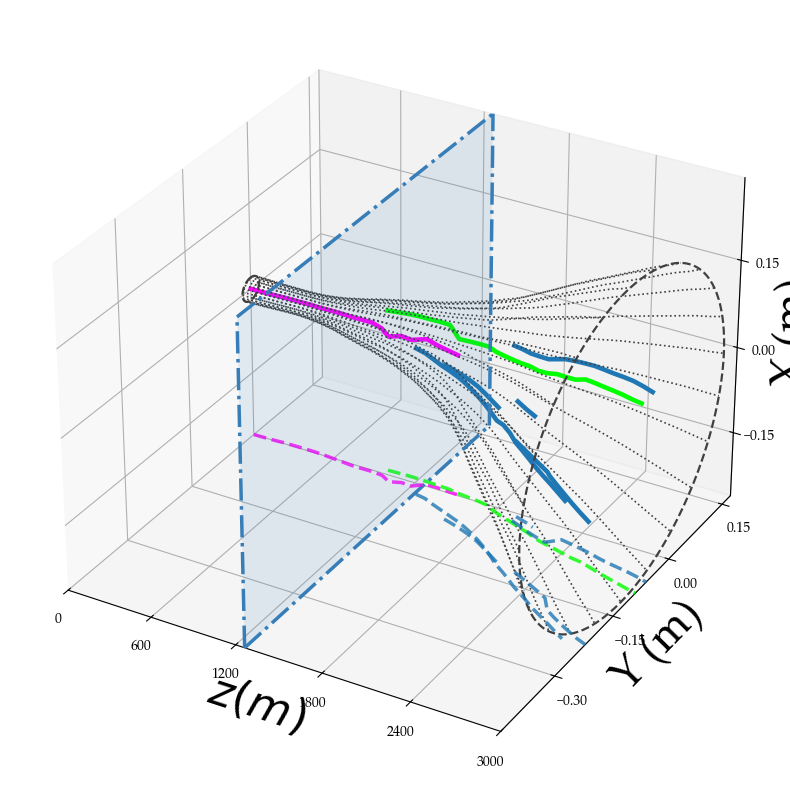

In [4]:

#! Imports -----
import numpy as np
import h5py, os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage import label, center_of_mass
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from skimage import measure
from matplotlib.path import Path
from matplotlib.ticker import MaxNLocator

#! Parameters -----

# Data Paths
base_data_path    = r'F:\FSO_Turbulence_Dataset\Propagation_Datasets'
metrics_base_path = r'F:\FSO_Turbulence_Dataset\Metrics_Data'

# Beam Parameters
wv1 = 500e-9
w0 = 0.020
#Propagation Parameters
L   = 3000.0
l0 = 0.005
PLOT_CN2 = 1e-13
# Grid Parameters
dim = 1024
# What iteration do you want to run? (0-499)
iteration = 412

# Projections control
DO_YZ_FLOOR_PROJECTION = True   # Project trajectories onto the floor (X = Xmin)
DO_XZ_WALL_PROJECTION = False # Project trajectories onto X–Z plane (Y = Ymin)

# Colors
COLOR_MAP = {
    (0.010, 0.005): '#e41a1c',
    (0.010, 0.050): "#810408",
    (0.020, 0.005): '#377eb8',
    (0.020, 0.050): "#063b6f",
}

# Sets complete decorrelation percent (Set to be close to 100 since it asymptotically approaches 0)
DECORR_LEVEL = 0.01

# Grid (meters)
xmax = np.sqrt(wv1 * L * dim)  # Satisfies critical sampling condition (See Voelz)
dx = xmax / dim
dy = dx
X_grid = (np.arange(dim) - dim // 2) * dx
Y_grid = (np.arange(dim) - dim // 2) * dy
X, Y = np.meshgrid(X_grid, Y_grid)

#! Functions -----

# Apply band pass (Used for tracking/associateion)
def get_bandpassed_spatial(intensity):
    fft_image = fftshift(fft2(intensity))
    h, w = intensity.shape
    cy, cx = h // 2, w // 2
    Yg, Xg = np.ogrid[:h, :w]
    distance = np.sqrt((Xg - cx)**2 + (Yg - cy)**2)
    mask = (distance >= 10) & (distance <= 80)  # Tuning if needed (Smooths tracking)
    return np.abs(ifft2(ifftshift(fft_image * mask)))

# Calculate the average radius of the 1/e^2 contour 
def compute_1e2_radius_px(Iraw, x, y):
    xi, yi = int(round(x)), int(round(y))
    if xi < 0 or xi >= Iraw.shape[1] or yi < 0 or yi >= Iraw.shape[0]:
        return 0.0
    peak = Iraw[yi, xi]
    if peak <= 0:
        return 0.0
    level = np.exp(-2) * peak
    contours = measure.find_contours(Iraw, level=level)
    for contour in contours:
        path = Path(contour[:, [1, 0]])
        if path.contains_point((x, y)):
            dxs = contour[:, 1] - x
            dys = contour[:, 0] - y
            return float(np.mean(np.sqrt(dxs**2 + dys**2)))
    return 0.0

# Calculate the centroid of the intensity profile and return offset profiles and coordinates
def centroid_calc(x, y, dx1, X, Y, U2, I2):
    x_cent = np.sum(np.sum(X * I2)) / np.sum(np.sum(I2))
    y_cent = np.sum(np.sum(Y * I2)) / np.sum(np.sum(I2))
    X2 = np.asarray(X) - x_cent
    Y2 = np.asarray(Y) - y_cent
    mx2 = round(x_cent / dx1)
    my2 = round(y_cent / dx1)
    u2_cent = np.roll(np.roll(U2, -mx2, axis=1), -my2, axis=0)
    I2_cent = np.roll(np.roll(I2, -mx2, axis=1), -my2, axis=0)
    return x_cent, y_cent, x - x_cent, y - y_cent, X2, Y2, None, u2_cent, I2_cent

# Calculate the mode field radius
def calc_mfr(signal, R2):
    num = np.sqrt(np.sum(np.sum(np.abs(signal)**2 * R2)))
    denom = np.sqrt(np.sum(np.sum(np.abs(signal)**2)))
    return np.sqrt(2) * num / denom

# Tracking Algorithm
#   - intensity_threshold_ratio: detection/association level (relative to current frame, very little change)
#   - death_floor_ratio: kill track if raw intensity drops below this fraction of original max
def track_hotspots_hf(hf, turb_key, z_range, intensity_threshold_ratio=0.3, death_floor_ratio=0.01):
    tracks = []
    initial_intensity_map = None
    original_max_intensity = None
    for z in z_range:
        U = hf[turb_key]['Uout_real'][z]
        I = np.abs(U)**2
        filt = get_bandpassed_spatial(I)
        if z == 0:
            initial_intensity_map = I.copy()
            original_max_intensity = float(np.max(I))
        max_f = float(np.max(filt))
        if max_f <= 0:
            for h in tracks:
                if h["alive"]:
                    h["alive"] = False
                    h["death_z"] = z
            continue
        mask = filt > (intensity_threshold_ratio * max_f)
        labeled, nfeat = label(mask)
        if nfeat == 0:
            for h in tracks:
                if h["alive"]:
                    h["alive"] = False
                    h["death_z"] = z
            continue
        centers = center_of_mass(filt, labeled, range(1, nfeat + 1))
        claimed = [False] * len(centers)
        for h in tracks:
            if not h["alive"]:
                continue
            lx, ly = h["last_pos"]
            r_thresh = max(1.0, float(h.get("min_avg_radius", 1.0)))
            best_i, best_d = None, np.inf
            for i, (cy, cx) in enumerate(centers):
                if claimed[i]:
                    continue
                d = np.hypot(cx - lx, cy - ly)
                if d <= r_thresh and d < best_d:
                    best_d, best_i = d, i
            if best_i is None:
                h["alive"] = False
                h["death_z"] = z
                continue
            cy, cx = centers[best_i]
            raw_at = I[int(round(cy)), int(round(cx))]
            if raw_at < death_floor_ratio * original_max_intensity:
                h["alive"] = False
                h["death_z"] = z
                claimed[best_i] = True
                continue
            h["last_pos"] = (cx, cy)
            h["track"].append((z, cx, cy))
            w_px = compute_1e2_radius_px(I, cx, cy)
            if not np.isfinite(w_px) or w_px < 1.0:
                w_px = 1.0
            h["radius_history"].append(w_px)
            rm = float(np.mean(h["radius_history"]))
            h["running_mean_radius"] = rm
            h["min_avg_radius"] = min(h["min_avg_radius"], rm)
            claimed[best_i] = True
        for i, (cy, cx) in enumerate(centers):
            if claimed[i]:
                continue
            reject = False
            for h in tracks:
                if not h["alive"]:
                    continue
                x0, y0 = h["last_pos"]
                r0 = max(1.0, float(h.get("min_avg_radius", 1.0)))
                if np.hypot(cx - x0, cy - y0) <= r0:
                    reject = True
                    break
            if reject:
                continue
            initI = initial_intensity_map[int(round(cy)), int(round(cx))]
            w_px = compute_1e2_radius_px(I, cx, cy)
            if not np.isfinite(w_px) or w_px < 1.0:
                w_px = 1.0
            tracks.append(dict(
                initial_pos=(cx, cy),
                last_pos=(cx, cy),
                alive=True,
                creation_z=z,
                death_z=None,
                track=[(z, cx, cy)],
                initial_intensity=float(initI),
                radius_history=[float(w_px)],
                running_mean_radius=float(w_px),
                min_avg_radius=float(w_px),
            ))
    lifetime_filter = 3
    tracks = [h for h in tracks if len(h["track"]) >= lifetime_filter]
    initial_indices = [i for i, h in enumerate(tracks) if h["creation_z"] == 0]
    longest_idx, max_life = -1, 0
    for i, h in enumerate(tracks):
        if i in initial_indices:
            continue
        c = h["creation_z"]
        d = h["death_z"] if h["death_z"] is not None else z_range[-1]
        life = d - c
        if life > max_life:
            max_life = life
            longest_idx = i
    return tracks, initial_indices, longest_idx

# Calculating the centroids of the speckles and global mode field radius
def mfr_and_centroids_for_run(file_path, X_grid, Y_grid, X, Y, dx, w0, wv1, L):
    with h5py.File(file_path, 'r') as hf:
        turb_key = list(hf.keys())[0]
        n_planes = hf[turb_key]['Uout_real'].shape[0]
        x_cent_m = np.zeros(n_planes)
        y_cent_m = np.zeros(n_planes)
        mfr_m = np.zeros(n_planes)
        for zi in range(n_planes):
            U = hf[turb_key]['Uout_real'][zi]
            I = np.abs(U)**2
            xc, yc, _, _, X2, Y2, _, Uc, _ = centroid_calc(X_grid, Y_grid, dx, X, Y, U, I)
            R2 = X2**2 + Y2**2
            x_cent_m[zi] = xc
            y_cent_m[zi] = yc
            mfr_m[zi] = calc_mfr(Uc, R2)
    zeta = np.linspace(0.0, L, n_planes)
    return zeta, x_cent_m, y_cent_m, mfr_m

# Converts the tracked positions to cartesian coordinates
def tracks_to_xyz(tracks, zeta, dx, dy, dim):
    out = []
    for h in tracks:
        seq = sorted(h["track"], key=lambda t: t[0])
        zids = np.asarray([t[0] for t in seq], dtype=int)
        xs = (np.asarray([t[1] for t in seq]) - dim/2.0) * dx
        ys = (np.asarray([t[2] for t in seq]) - dim/2.0) * dy
        out.append((zeta[zids], ys, xs))
    return out

# Apply colors
def color_for(i, initial_indices, longest_idx):
    if i in initial_indices: return 'magenta'
    if i == longest_idx: return 'lime'
    return 'tab:blue'

# Pull magnitude-squared coherence data (Only required if plotting decorrelation plane)
def _read_corr_for_combo_3d(cn2, w0, l0):
    metrics_path = os.path.join(metrics_base_path, f"Cn2_{cn2}_Metrics_Data.h5")
    if not os.path.exists(metrics_path):
        return None
    with h5py.File(metrics_path, 'r') as hf:
        base = f"w0={w0}_Cn2={cn2}_l0={l0}_l=0_p=0_iteration="
        stacks, nz_expected = [], None
        for it in range(500):
            key = base + str(it)
            if key not in hf:
                continue
            grp = hf[key]
            if 'Correlation' not in grp:
                continue
            arr = np.asarray(grp['Correlation'][:], dtype=float)
            if arr.ndim != 1 or arr.size == 0 or not np.isfinite(arr).any():
                continue
            if nz_expected is None:
                nz_expected = arr.size
            if arr.size != nz_expected:
                continue
            stacks.append(arr)
    if not stacks:
        return None
    stack = np.stack(stacks, axis=0)
    avg = np.nanmean(stack, axis=0)
    z = np.linspace(0.0, L, avg.size)
    return z, np.clip(avg, 0.0, 1.0)

# Calculating the first z distance that has a decorrelation distance <= 1%
def _first_crossing_z(z_arr, y_arr, level):
    for i in range(1, len(y_arr)):
        y0, y1 = y_arr[i-1], y_arr[i]
        if (y0 >= level) and (y1 <= level):
            z0, z1 = z_arr[i-1], z_arr[i]
            if y0 == y1:
                return z1
            t = (level - y0) / (y1 - y0)
            return z0 + t * (z1 - z0)
    return None

#! Main Code -----

# Pulling in the correct data
beam_key_base = f"w0={w0}_Cn2={PLOT_CN2}_l0={l0}_l=0_p=0"
file_path = os.path.join(base_data_path, f"Prop_Dataset_Cn2_{PLOT_CN2}",
                         f"{beam_key_base}_iteration={iteration}.h5")

# Reading the data and tracking the speckles
with h5py.File(file_path, 'r') as hf:
    turb_key = list(hf.keys())[0]
    n_planes = hf[turb_key]['Uout_real'].shape[0]
    zeta = np.linspace(0.0, L, n_planes)
    tracks, initial_indices, longest_idx = track_hotspots_hf(
        hf, turb_key, range(n_planes)
    )
    
# Calculating the mode field radius and centroids
zeta_run, x_cent_m, y_cent_m, mfr_m = mfr_and_centroids_for_run(
    file_path, X_grid, Y_grid, X, Y, dx, w0, wv1, L
)

# Convert the trajectories to cartesian coordinates for plotting
trajectories = tracks_to_xyz(tracks, zeta_run, dx, dy, dim)

# Get decorrelation distance
decor_z = None
corr_res = _read_corr_for_combo_3d(PLOT_CN2, w0, l0)
if corr_res is not None:
    z_corr, avg_corr = corr_res
    decor_z = _first_crossing_z(z_corr, avg_corr, DECORR_LEVEL)

#! Plotting -----
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw main trajectories
for i, (z_, y_, x_) in enumerate(trajectories):
    ax.plot(z_, y_, x_, color=color_for(i, initial_indices, longest_idx), linewidth=3.3)

# MFR wire cone
n_spokes = 24
angles = np.linspace(0, 2*np.pi, n_spokes, endpoint=False)
for th in angles:
    x_edge = x_cent_m + mfr_m * np.cos(th)
    y_edge = y_cent_m + mfr_m * np.sin(th)
    ax.plot(zeta_run, y_edge, x_edge, color='0.25', linestyle=':', linewidth=1.2)

# Cross-sections
theta = np.linspace(0, 2*np.pi, 240)
for zid in (0, len(zeta_run)-1):
    ax.plot(np.full_like(theta, zeta_run[zid]),
            y_cent_m[zid] + mfr_m[zid]*np.sin(theta),
            x_cent_m[zid] + mfr_m[zid]*np.cos(theta),
            color='0.25', linestyle='--', linewidth=1.6)

# Labels and ticks
ax.set_xlabel(r'$z (m)$', fontsize=32)
ax.set_ylabel('Y (m)', fontsize=32)
ax.set_zlabel('X (m)', fontsize=32)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.zaxis.set_major_locator(MaxNLocator(nbins=5))

# Freeze limits before adding plane
ax.set_xlim(0, 3000)
ax.set_xticks(np.linspace(0, 3000, 6))
ymin, ymax = ax.get_ylim()
zmin, zmax = ax.get_zlim()
ax.set_ylim(ymin, ymax)
ax.set_zlim(zmin, zmax)

# Decorrelation plane (only for this combo)
if decor_z is not None and 0.0 <= decor_z <= L:
    plane_color = COLOR_MAP.get((w0, l0), '#555555')
    plane_vertices = [
        (decor_z, ymin, zmin),
        (decor_z, ymax, zmin),
        (decor_z, ymax, zmax),
        (decor_z, ymin, zmax),
    ]
    poly = Poly3DCollection([plane_vertices],
                            facecolor=plane_color,
                            alpha=0.12,
                            edgecolor='none')
    ax.add_collection3d(poly)
    for ypair, zpair in [([ymin, ymax], [zmin, zmin]),
                         ([ymin, ymax], [zmax, zmax]),
                         ([ymin, ymin], [zmin, zmax]),
                         ([ymax, ymax], [zmin, zmax])]:
        ax.plot([decor_z, decor_z], ypair, zpair,
                color=plane_color, linestyle='-.', linewidth=2.5)

# Projections 
if DO_YZ_FLOOR_PROJECTION:
    x_floor = zmin
    for i, (z_, y_, x_) in enumerate(trajectories):
        col = color_for(i, initial_indices, longest_idx)
        ax.plot(z_, y_, np.full_like(z_, x_floor),
                color=col, linestyle='--', linewidth=2.5, alpha=0.8)

if DO_XZ_WALL_PROJECTION:
    y_wall = ymax
    for i, (z_, y_, x_) in enumerate(trajectories):
        col = color_for(i, initial_indices, longest_idx)
        ax.plot(z_, np.full_like(z_, y_wall), x_,
                color=col, linestyle='--', linewidth=2.5, alpha=0.5)

plt.tight_layout()

# Uncomment to save the image
'''fig_dir = os.path.join(os.path.dirname(base_data_path), "Figures")
os.makedirs(fig_dir, exist_ok=True)
out_path = os.path.join(fig_dir, f"Trajectories3D_w0_{w0}_l0_{l0}_Cn2_{PLOT_CN2:.0e}_it{iteration}.svg")
plt.savefig(out_path, dpi=300)
print("Saved:", out_path)'''

plt.show()



# 2D Animation Of Tracking Algorithm

Rytov Parameter Array: [0.         0.84348858 1.59229441 2.36330329]


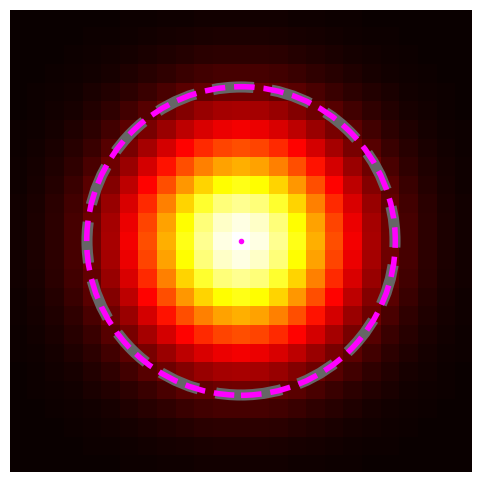

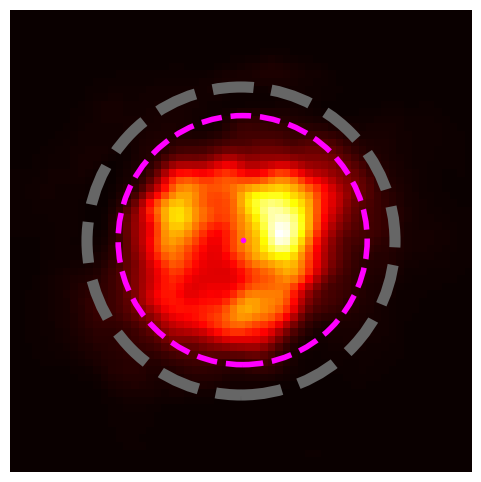

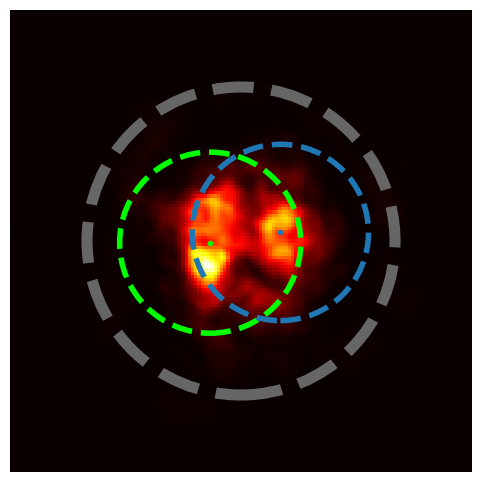

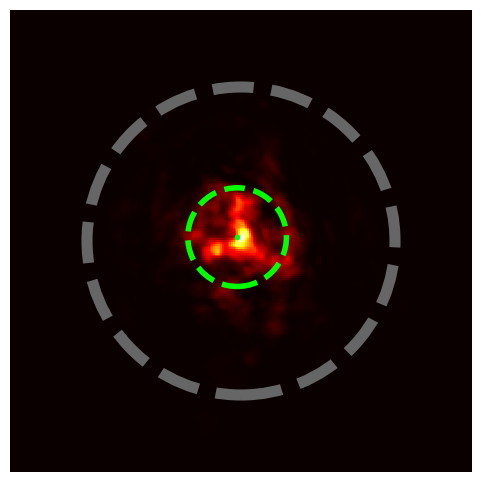

In [5]:

#! Imports --------------------------------------------------
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.ndimage import label, center_of_mass
from skimage import measure
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from matplotlib.path import Path

#! Parameters ------------------------------------------------

# Data paths
base_data_path = r'F:\FSO_Turbulence_Dataset\Propagation_Datasets'
anim_dir       = r"F:\FSO_Turbulence_Dataset\Prop Animations"
fig_dir        = os.path.join(os.path.dirname(base_data_path), "Figures")
#os.makedirs(anim_dir, exist_ok=True)
#os.makedirs(fig_dir,  exist_ok=True)

# Beam / turbulence parameters
cn2 = 1e-14
l0  = 0.005
rad = 0.01         # w0
L   = 3000         # [m]
wv1 = 500e-9       # [m]

# Dataset naming
beam_key_base = f"w0={rad}_Cn2={cn2}_l0={l0}_l=0_p=0"
file_path     = os.path.join(
    base_data_path,
    f'Prop_Dataset_Cn2_{cn2}',
    f'{beam_key_base}_iteration=411.h5'
)

# Grid parameters
dim  = 1024
xmax = np.sqrt(wv1 * L * dim)  # Critical sampling condition (See Voelz)
dx   = xmax / dim
X_grid = (np.arange(dim) - dim // 2) * dx
Y_grid = (np.arange(dim) - dim // 2) * dx
X, Y   = np.meshgrid(X_grid, Y_grid)

# Crop / window control
USE_DYNAMIC_WINDOW   = True     # if True, window follows MFR
WINDOW_MFR_MULTIPLIER = 1.5
STATIC_HALF_SIZE_PX   = 250
WINDOW_MIN_HALF_PX    = 8
WINDOW_MAX_HALF_PX    = dim // 2 - 2  # prevent going out of bounds

#! Functions -------------------------------------------------

# Bandpass filter in spatial frequency (used for detection/association)
def get_bandpassed_spatial(intensity):
    fft_image = fftshift(fft2(intensity))
    h, w = intensity.shape
    cy, cx = h // 2, w // 2
    Yg, Xg = np.ogrid[:h, :w]
    distance = np.sqrt((Xg - cx)**2 + (Yg - cy)**2)
    # Tuning band
    mask = (distance >= 10) & (distance <= 80)
    filtered_fft = fft_image * mask
    return np.abs(ifft2(ifftshift(filtered_fft)))

# Compute average 1/e^2 radius (in px) of a spot centered at (x, y)
def compute_1e2_radius_px(Iraw, x, y):
    x_int = int(round(x))
    y_int = int(round(y))
    if x_int < 0 or x_int >= Iraw.shape[1] or y_int < 0 or y_int >= Iraw.shape[0]:
        return 0.0
    peak = Iraw[y_int, x_int]
    if peak <= 0:
        return 0.0
    level = np.exp(-2) * peak
    contours = measure.find_contours(Iraw, level=level)
    for contour in contours:
        # contour points come as (row, col) -> (y, x)
        path = Path(contour[:, [1, 0]])
        if path.contains_point((x, y)):
            dxs = contour[:, 1] - x
            dys = contour[:, 0] - y
            return float(np.mean(np.sqrt(dxs**2 + dys**2)))
    return 0.0

# Center by intensity centroid and return fields
def centroid_calc(x, y, dx1, X, Y, U2, I2):
    x_cent = np.sum(np.sum(X * I2)) / np.sum(np.sum(I2))
    y_cent = np.sum(np.sum(Y * I2)) / np.sum(np.sum(I2))
    X2 = np.asarray(X) - x_cent
    Y2 = np.asarray(Y) - y_cent
    mx2 = round(x_cent / dx1)
    my2 = round(y_cent / dx1)
    # integer-roll to center
    U2_cent = np.roll(np.roll(U2, -mx2, axis=1), -my2, axis=0)
    I2_cent = np.roll(np.roll(I2, -mx2, axis=1), -my2, axis=0)
    # return consistent tuple (match your earlier code style)
    return x_cent, y_cent, x - x_cent, y - y_cent, X2, Y2, None, U2_cent, I2_cent

# Second-moment mode field radius (in meters)
def calc_mfr(signal, R2):
    num   = np.sqrt(np.sum(np.sum(np.abs(signal)**2 * R2)))
    denom = np.sqrt(np.sum(np.sum(np.abs(signal)**2)))
    return np.sqrt(2) * num / denom

# Build centered crop bounds (for display)
def static_window_limits(W, H, half_size_px, origin_upper=True):
    half = float(max(half_size_px, 1.0))
    cx = W / 2.0
    cy = H / 2.0
    x0 = max(0.0, cx - half)
    x1 = min(float(W), cx + half)
    y0 = max(0.0, cy - half)
    y1 = min(float(H), cy + half)
    if origin_upper:
        return (x0, x1, y1, y0)
    else:
        return (x0, x1, y0, y1)

# Choose window half-size based on MFR
def choose_half_size_px(mfr_px, use_dynamic=USE_DYNAMIC_WINDOW):
    if use_dynamic:
        if not np.isfinite(mfr_px) or mfr_px <= 0:
            half = STATIC_HALF_SIZE_PX
        else:
            half = WINDOW_MFR_MULTIPLIER * float(mfr_px)
    else:
        half = float(STATIC_HALF_SIZE_PX)
    # clamp
    half = max(WINDOW_MIN_HALF_PX, min(WINDOW_MAX_HALF_PX, half))
    return half

# Tracking algorithm
#   - intensity_threshold_ratio: detection/association level (relative to current frame)
#   - death_floor_ratio: kill track if raw intensity drops below this fraction of original max
def track_hotspots(hf, turb_key, z_range, intensity_threshold_ratio=0.8, death_floor_ratio=0.01):
    hotspot_tracks = []
    original_max_intensity = None
    initial_intensity_map  = None

    for z in z_range:
        Uz = hf[turb_key]['Uout_real'][z]
        Iz = np.abs(Uz)**2
        filtered = get_bandpassed_spatial(Iz)
        
        if z == 0:
            initial_intensity_map  = Iz.copy()
            original_max_intensity = float(np.max(Iz))
        max_filtered = float(np.max(filtered))
        
        if max_filtered <= 0:
            for hotspot in hotspot_tracks:
                if hotspot["alive"]:
                    hotspot["alive"] = False
                    hotspot["death_z"] = z
            continue
        
        mask = filtered > (intensity_threshold_ratio * max_filtered)
        labeled, num_features = label(mask)
        if num_features == 0:
            for hotspot in hotspot_tracks:
                if hotspot["alive"]:
                    hotspot["alive"] = False
                    hotspot["death_z"] = z
            continue
        current_centers = center_of_mass(filtered, labeled, range(1, num_features + 1))
        claimed = [False] * len(current_centers)
        
        for hotspot in hotspot_tracks:
            if not hotspot["alive"]:
                continue
            last_x, last_y = hotspot["last_pos"]
            r_thresh = max(1.0, float(hotspot.get("min_avg_radius", 1.0)))

            best_i, best_d = None, np.inf
            for i, (y, x) in enumerate(current_centers):
                if claimed[i]:
                    continue
                d = np.hypot(x - last_x, y - last_y)
                if d <= r_thresh and d < best_d:
                    best_d = d
                    best_i = i

            if best_i is not None:
                y, x = current_centers[best_i]
                intensity_at_spot = Iz[int(round(y)), int(round(x))]
                if intensity_at_spot < death_floor_ratio * original_max_intensity:
                    hotspot["alive"] = False
                    hotspot["death_z"] = z
                else:
                    hotspot["last_pos"] = (x, y)
                    hotspot["track"].append((z, x, y))
                    width_px = float(compute_1e2_radius_px(Iz, x, y))
                    if not np.isfinite(width_px) or width_px < 1.0:
                        width_px = 1.0
                    hotspot["radius_history"].append(width_px)
                    running_mean = float(np.mean(hotspot["radius_history"]))
                    hotspot["running_mean_radius"] = running_mean
                    hotspot["min_avg_radius"]     = min(hotspot["min_avg_radius"], running_mean)
                claimed[best_i] = True
            else:
                hotspot["alive"]  = False
                hotspot["death_z"] = z

        for i, (y, x) in enumerate(current_centers):
            if claimed[i]:
                continue
            reject = False
            for h in hotspot_tracks:
                if not h["alive"]:
                    continue
                x0, y0 = h["last_pos"]
                r0 = max(1.0, float(h.get("min_avg_radius", 1.0)))
                if np.hypot(x - x0, y - y0) <= r0:
                    reject = True
                    break
            if reject:
                continue

            initial_intensity = initial_intensity_map[int(round(y)), int(round(x))]
            width_px = float(compute_1e2_radius_px(Iz, x, y))
            if not np.isfinite(width_px) or width_px < 1.0:
                width_px = 1.0

            hotspot_tracks.append({
                "initial_pos": (x, y),
                "last_pos":    (x, y),
                "alive":       True,
                "creation_z":  z,
                "death_z":     None,
                "track":       [(z, x, y)],
                "initial_intensity": float(initial_intensity),
                "width_px":          width_px,
                "radius_history":    [width_px],
                "running_mean_radius": width_px,
                "min_avg_radius":      width_px,
            })

    # prune short-lived tracks
    lifetime_filter = 3
    hotspot_tracks = [h for h in hotspot_tracks if len(h["track"]) >= lifetime_filter]

    # indices of those created at z=0
    initial_indices = [i for i, h in enumerate(hotspot_tracks) if h["creation_z"] == 0]

    # longest-living non-initial track
    longest_idx, max_lifetime = -1, 0
    for i, h in enumerate(hotspot_tracks):
        if i in initial_indices:
            continue
        creation = h["creation_z"]
        death    = h["death_z"] if h["death_z"] is not None else z_range[-1]
        lifetime = death - creation
        if lifetime > max_lifetime:
            max_lifetime = lifetime
            longest_idx  = i

    return hotspot_tracks, initial_indices, longest_idx

#! Determine z-range -----------------------------------------

with h5py.File(file_path, 'r') as _hf:
    _turb_key = list(_hf.keys())[0]
    n_planes  = _hf[_turb_key]['Uout_real'].shape[0]
z_range = range(n_planes)

#! Run tracking ----------------------------------------------

with h5py.File(file_path, 'r') as hf:
    turb_key = list(hf.keys())[0]
    hotspot_tracks, initial_indices, longest_idx = track_hotspots(
        hf,
        turb_key,
        z_range,
        intensity_threshold_ratio=0.3, 
        death_floor_ratio=0.01
    )

#! Uncomment to save gif
'''#! Animation setup -------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

def update(frame):
    ax.clear()
    with h5py.File(file_path, 'r') as hf:
        Uz = hf[turb_key]['Uout_real'][frame]
        Iz = np.abs(Uz)**2

        # center this frame
        x_cent, y_cent, _, _, X2, Y2, _, Uz_c, Iz_c = centroid_calc(
            X_grid, Y_grid, dx, X, Y, Uz, Iz
        )
        R2     = X2**2 + Y2**2
        mfr_m  = calc_mfr(Uz_c, R2)
        mfr_px = float(mfr_m / dx)

        # base intensity (contours)
        levels = np.linspace(np.min(Iz_c), np.max(Iz_c), 15)
        ax.contour(Iz_c, levels=levels, cmap='hot', linewidths=1.0)

        # MFR circle
        cx = dim / 2.0
        cy = dim / 2.0
        ax.add_patch(
            patches.Circle(
                (cx, cy),
                radius=mfr_px,
                fill=False,
                edgecolor='0.4',
                linewidth=2.0,
                linestyle='-',
                zorder=8
            )
        )
        
        mx2 = int(round(x_cent / dx))
        my2 = int(round(y_cent / dx))

        # overlay hotspots for this frame
        for idx, hotspot in enumerate(hotspot_tracks):
            positions = [p for p in hotspot["track"] if p[0] == frame]
            if not positions:
                continue
            _, x, y = positions[0]
            x_c = x - mx2
            y_c = y - my2
            x_int = int(round(x_c))
            y_int = int(round(y_c))
            if x_int < 0 or x_int >= dim or y_int < 0 or y_int >= dim:
                continue

            if idx in initial_indices:
                color = 'magenta'
            elif idx == longest_idx:
                color = 'lime'
            else:
                color = 'tab:blue'

            r_px = compute_1e2_radius_px(Iz_c, x_c, y_c)
            if not np.isfinite(r_px) or r_px <= 0:
                r_px = 6.0

            ax.add_patch(
                patches.Circle(
                    (x_c, y_c),
                    radius=r_px,
                    fill=False,
                    edgecolor=color,
                    linewidth=2.0,
                    linestyle='--',
                    zorder=10
                )
            )
            ax.plot(
                x_c, y_c,
                marker='o',
                markersize=3.0,
                color=color,
                linestyle='None',
                zorder=11
            )

        # window / crop
        half_size_px = choose_half_size_px(mfr_px, USE_DYNAMIC_WINDOW)
        x0, x1, y_top, y_bot = static_window_limits(dim, dim, half_size_px, origin_upper=True)
        ax.set_xlim(x0, x1)
        ax.set_ylim(y_top, y_bot)
        ax.set_aspect('equal')
        ax.axis('off')

    return ax.patches + ax.texts + ax.collections

ani = FuncAnimation(fig, update, frames=z_range, interval=300, blit=False)
gif_output = os.path.join(anim_dir, "hotspot_track.gif")
ani.save(gif_output, writer=PillowWriter(fps=3), dpi=150)
plt.close()
print("Saved animation:", gif_output)'''

#! Static snapshots ------------------------------------------

with h5py.File(file_path, 'r') as hf:
    turb_key = list(hf.keys())[0]
    U = hf[turb_key]['Uout_real']
    n_planes_check = U.shape[0]

    # pick z indices
    z_idx_list = [
        0,
        int(round((n_planes_check - 1) * 0.33)),
        int(round((n_planes_check - 1) * 0.66)),
        int(round((n_planes_check - 1) * 1.00)),
    ]
    z_planes_m = np.linspace(0.0, L, n_planes_check)

    # quick Rytov diagnostic
    zzz = np.asarray([0, 975, 1950, 3000])
    print(rf'Rytov Parameter Array: {np.sqrt(1.23 * cn2 * (2 * np.pi / wv1) ** (7/6) * zzz ** (11/6))}')

    saved_paths = []
    for idx in z_idx_list:
        Uz = U[idx]
        Iz = np.abs(Uz)**2

        # center
        x_cent, y_cent, _, _, X2, Y2, _, Uz_c, Iz_c = centroid_calc(
            X_grid, Y_grid, dx, X, Y, Uz, Iz
        )
        R2     = X2**2 + Y2**2
        mfr_m  = calc_mfr(Uz_c, R2)
        mfr_px = float(mfr_m / dx)

        H, W = Iz_c.shape
        vmax_local = max(float(np.max(Iz_c)), 1e-12)

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(
            Iz_c,
            cmap='hot',
            origin='lower',
            interpolation='nearest',
            vmin=0.0,
            vmax=vmax_local
        )

        # MFR circle
        cx = W / 2.0
        cy = H / 2.0
        ax.add_patch(
            patches.Circle(
                (cx, cy),
                radius=mfr_px,
                fill=False,
                edgecolor=".4",
                linewidth=8,
                linestyle='--',
                zorder=8
            )
        )

        mx2 = int(round(x_cent / dx))
        my2 = int(round(y_cent / dx))

        # overlay all tracked speckles at this z
        for h_idx, hotspot in enumerate(hotspot_tracks):
            pos = next((p for p in hotspot["track"] if p[0] == idx), None)
            if pos is None:
                continue
            _, x, y = pos
            x_c = x - mx2
            y_c = y - my2
            if not (0 <= x_c < W and 0 <= y_c < H):
                continue

            if h_idx in initial_indices:
                color = 'magenta'
            elif h_idx == longest_idx:
                color = 'lime'
            else:
                color = 'tab:blue'

            r_px = compute_1e2_radius_px(Iz_c, x_c, y_c)
            if not np.isfinite(r_px) or r_px <= 0:
                r_px = 6.0

            ax.add_patch(
                patches.Circle(
                    (x_c, y_c),
                    r_px,
                    fill=False,
                    edgecolor=color,
                    linewidth=4.0,
                    linestyle='--',
                    zorder=10
                )
            )
            ax.plot(
                x_c, y_c,
                marker='o',
                markersize=3.0,
                color=color,
                linestyle='None',
                zorder=11
            )

        # crop to MFR-based window
        half_size_px = choose_half_size_px(mfr_px, USE_DYNAMIC_WINDOW)
        x0, x1, y0, y1 = static_window_limits(W, H, half_size_px, origin_upper=False)
        ax.set_xlim(x0, x1)
        ax.set_ylim(y0, y1)
        ax.set_aspect('equal')
        ax.axis('off')

        z_m     = float(z_planes_m[idx])
        
        #Uncomment to save 
        '''out_path = os.path.join(
            fig_dir,
            f'heatmap_window_{("dyn" if USE_DYNAMIC_WINDOW else "static")}_z{int(round(z_m))}m.png'
        )
        fig.savefig(out_path, bbox_inches='tight', dpi=300)
        plt.close(fig)
        saved_paths.append(out_path)'''
        plt.show()


# Magnitude-squared decoherence

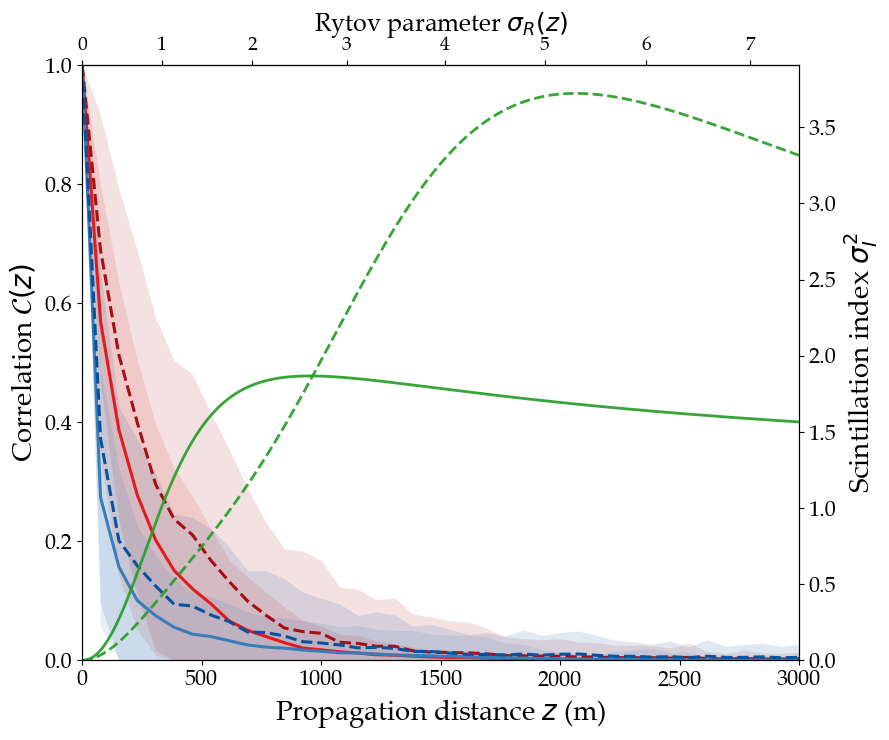

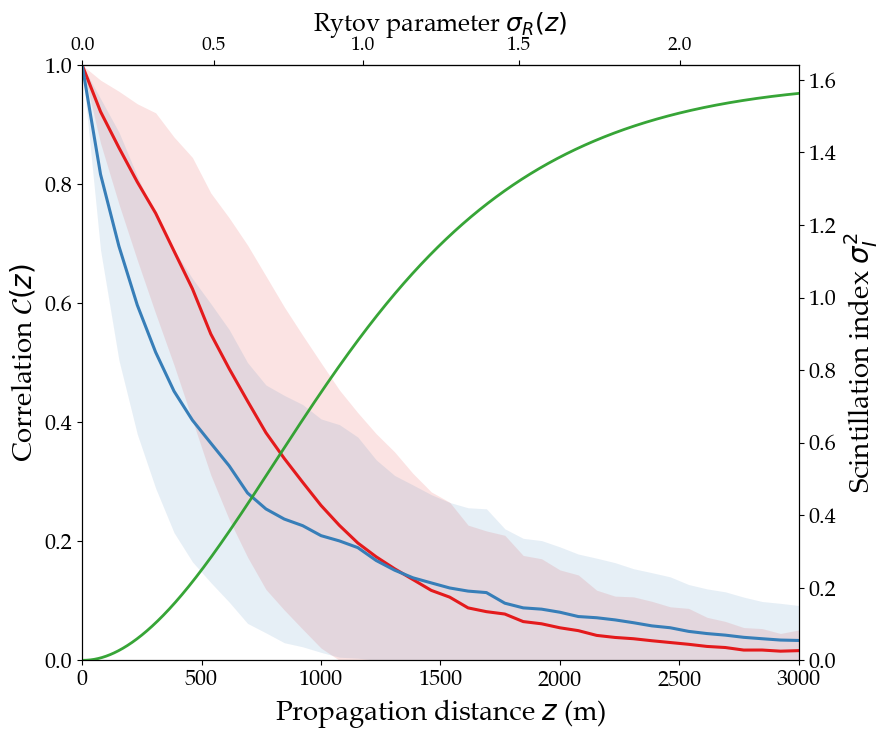

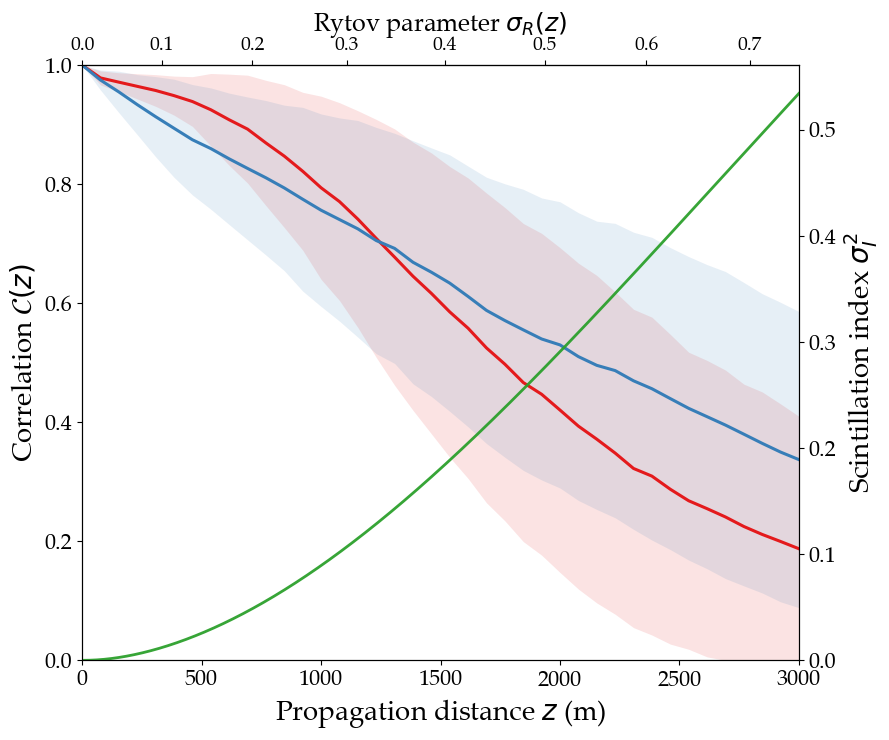

In [8]:
#! Imports -----
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

#! Parameters -----
metrics_base_path = r'F:\FSO_Turbulence_Dataset\Metrics_Data'
fig_save_path     = r'F:\FSO_Turbulence_Dataset\Figures'
os.makedirs(fig_save_path, exist_ok=True)

# Turbulence / beam sweeps
cn2_vals = [1e-13, 1e-14, 1e-15]
w0_vals  = [0.010, 0.020]
l0_vals  = [0.005, 0.050]

# Propagation / optics
L   = 3000.0          # max plotted path length [m]
wv1 = 500e-9          # wavelength [m]
l   = 0               # LG indices (kept for filename consistency)
p   = 0
ITERATION_RANGE = range(500)  # number of metrics iterations to aggregate

# Visual mappings
LSTYLE_MAP = {0.005: '-', 0.050: '--'}   # inner-scale -> linestyle
COLOR_MAP = {
    (0.010, 0.005): '#e41a1c',
    (0.010, 0.050): '#a50f15',
    (0.020, 0.005): '#377eb8',
    (0.020, 0.050): '#08519c',
}
SI_COLOR = '#2ca02c'  # color for scintillation index curves


#! Rytov / scintillation models -----
def rytov_sigma1_pw(cn2, z, wv):
    k = 2.0 * np.pi / wv
    z = np.maximum(z, 0.0)
    return np.sqrt(1.23 * cn2 * (k ** (7.0 / 6.0)) * (z ** (11.0 / 6.0)))


def scint_index_vs_z(cn2, l0, wv, Lmax=3000.0, npts=3000):
    k = 2.0 * np.pi / wv
    z = np.linspace(1.0, Lmax, npts)

    # Base plane-wave Rytov variance
    rytov2 = 1.23 * cn2 * (k ** (7.0 / 6.0)) * (z ** (11.0 / 6.0))
    root_rytov = np.sqrt(rytov2)

    # Inner-scale factor
    Ql = 10.89 * z / (k * (l0 ** 2))
    etaxp = 3.0 / (1.0 + 0.50 * rytov2 * (Ql ** (1.0 / 6.0)))
    frac = (etaxp * Ql) / (etaxp + Ql)

    # Log-amplitude scintillation
    log_scint = 0.15 * rytov2 * (frac ** (7.0 / 6.0)) * (
        1.0 + 1.753 * (etaxp / (etaxp + Ql)) ** 0.5
        - 0.252 * (etaxp / (etaxp + Ql)) ** (7.0 / 12.0)
    )

    # Convert to intensity scintillation
    scint_plane = np.exp(
        log_scint + (0.509 * rytov2 / (1.0 + 0.69 * (root_rytov ** (12.0 / 5.0))) ** (5.0 / 6.0))
    ) - 1.0
    return z, scint_plane


#! Correlation aggregation from HDF5 -----
def _read_corr_for_combo(hf, cn2, w0, l0):
    base = f"w0={w0}_Cn2={cn2}_l0={l0}_l={l}_p={p}_iteration="
    stacks = []
    nz_expected = None

    for it in ITERATION_RANGE:
        key = base + str(it)
        if key not in hf:
            continue
        grp = hf[key]
        if 'Correlation' not in grp:
            continue

        arr = np.asarray(grp['Correlation'][:], dtype=float)
        if arr.ndim != 1 or arr.size == 0 or not np.isfinite(arr).any():
            continue

        if nz_expected is None:
            nz_expected = arr.size
        if arr.size != nz_expected:
            continue

        stacks.append(arr)

    if not stacks:
        return None
    return np.stack(stacks, axis=0)


def aggregate_corr(cn2, w0, l0):
    path = os.path.join(metrics_base_path, f"Cn2_{cn2}_Metrics_Data.h5")
    if not os.path.exists(path):
        return None

    with h5py.File(path, 'r') as hf:
        stack = _read_corr_for_combo(hf, cn2, w0, l0)

    if stack is None:
        return None

    avg = np.nanmean(stack, axis=0)
    std = np.nanstd(stack, axis=0)

    if avg.size > 0:
        avg[0] = 1.0

    avg_c = np.clip(avg, 0.0, 1.0)
    lo    = np.clip(avg - std, 0.0, 1.0)
    hi    = np.clip(avg + std, 0.0, 1.0)
    z     = np.linspace(0.0, L, avg.size)

    return dict(z=z, avg=avg_c, lo=lo, hi=hi)


#! Plotting routine (corr + scint vs z, with top σ_R axis) -----
def plot_for_cn2_corr_plus_scint_z(cn2, save=True):

    combos = [(w0, l0) for w0 in w0_vals for l0 in l0_vals]

    fig, ax_left = plt.subplots(figsize=(9, 7.5))
    ax_right = ax_left.twinx()

    for ax in (ax_left, ax_right):
        ax.tick_params(axis='both', which='both', labelsize=16)

    seen_l0_for_si = set()
    si_max = 0.0

    # --- correlation curves (left) + scint curves (right) ---
    for (w0, l0) in combos:
        res = aggregate_corr(cn2, w0, l0)
        if res is None:
            continue

        color  = COLOR_MAP.get((w0, l0), '0.3')
        lstyle = LSTYLE_MAP.get(l0, '-')
        label_corr = rf"$w_0={w0:.3f}$, $\ell_0={l0:.3f}$"

        ax_left.plot(res['z'], res['avg'],
                     label=label_corr,
                     color=color,
                     linestyle=lstyle,
                     linewidth=2.2)
        ax_left.fill_between(res['z'], res['lo'], res['hi'],
                             color=color, alpha=0.12, linewidth=0.0)

        if l0 not in seen_l0_for_si:
            seen_l0_for_si.add(l0)
            z_si, scint = scint_index_vs_z(cn2, l0, wv1, Lmax=L, npts=3000)
            ax_right.plot(z_si, scint,
                          color=SI_COLOR,
                          linestyle=lstyle,
                          linewidth=2.0,
                          alpha=0.95,
                          label=rf"SI, $\ell_0={l0:.3f}$")

            if scint.size:
                si_max = max(si_max, float(np.nanmax(scint)))

    # --- axis ticks/labels ---
    ax_left.set_xlim(0.0, L)
    ax_left.set_ylim(0.0, 1.0)
    ax_left.set_xlabel(r"Propagation distance $z$ (m)", fontsize=20)
    ax_left.set_ylabel(r"Correlation $\mathcal{C}(z)$", fontsize=20)

    if si_max <= 0 or not np.isfinite(si_max):
        si_max = 1.0
    ax_right.set_ylim(0.0, si_max * 1.05)
    ax_right.set_ylabel(r"Scintillation index $\sigma_I^2$", fontsize=20)

    def z_to_sigmaR(z):
        return rytov_sigma1_pw(cn2, np.array(z), wv1)

    def sigmaR_to_z(sigma_r):
        k = 2.0 * np.pi / wv1
        return ((sigma_r ** 2) / (1.23 * cn2 * (k ** (7.0 / 6.0)))) ** (6.0 / 11.0)

    secax = ax_left.secondary_xaxis('top',
                                    functions=(z_to_sigmaR, sigmaR_to_z))
    secax.set_xlabel(r"Rytov parameter $\sigma_R(z)$", fontsize=18)
    secax.tick_params(axis='x', labelsize=14)

    # legends: left for correlation, right for scint
    #ax_left.legend(loc='upper left', fontsize=11, frameon=False)
    #ax_right.legend(loc='upper right', fontsize=11, frameon=False)

    plt.tight_layout()

    if save:
        out = os.path.join(fig_save_path, f"Corr_and_Scint_vs_z_Cn2_{cn2:g}.svg")
        plt.savefig(out, format='svg')
        print(f"[saved] {out}")

    return fig


#! Main -----
def main():
    for cn2 in cn2_vals:
        # Change save to True if you want to save
        plot_for_cn2_corr_plus_scint_z(cn2, save=False)
    plt.show()


if __name__ == "__main__":
    main()



# Speckle Widths

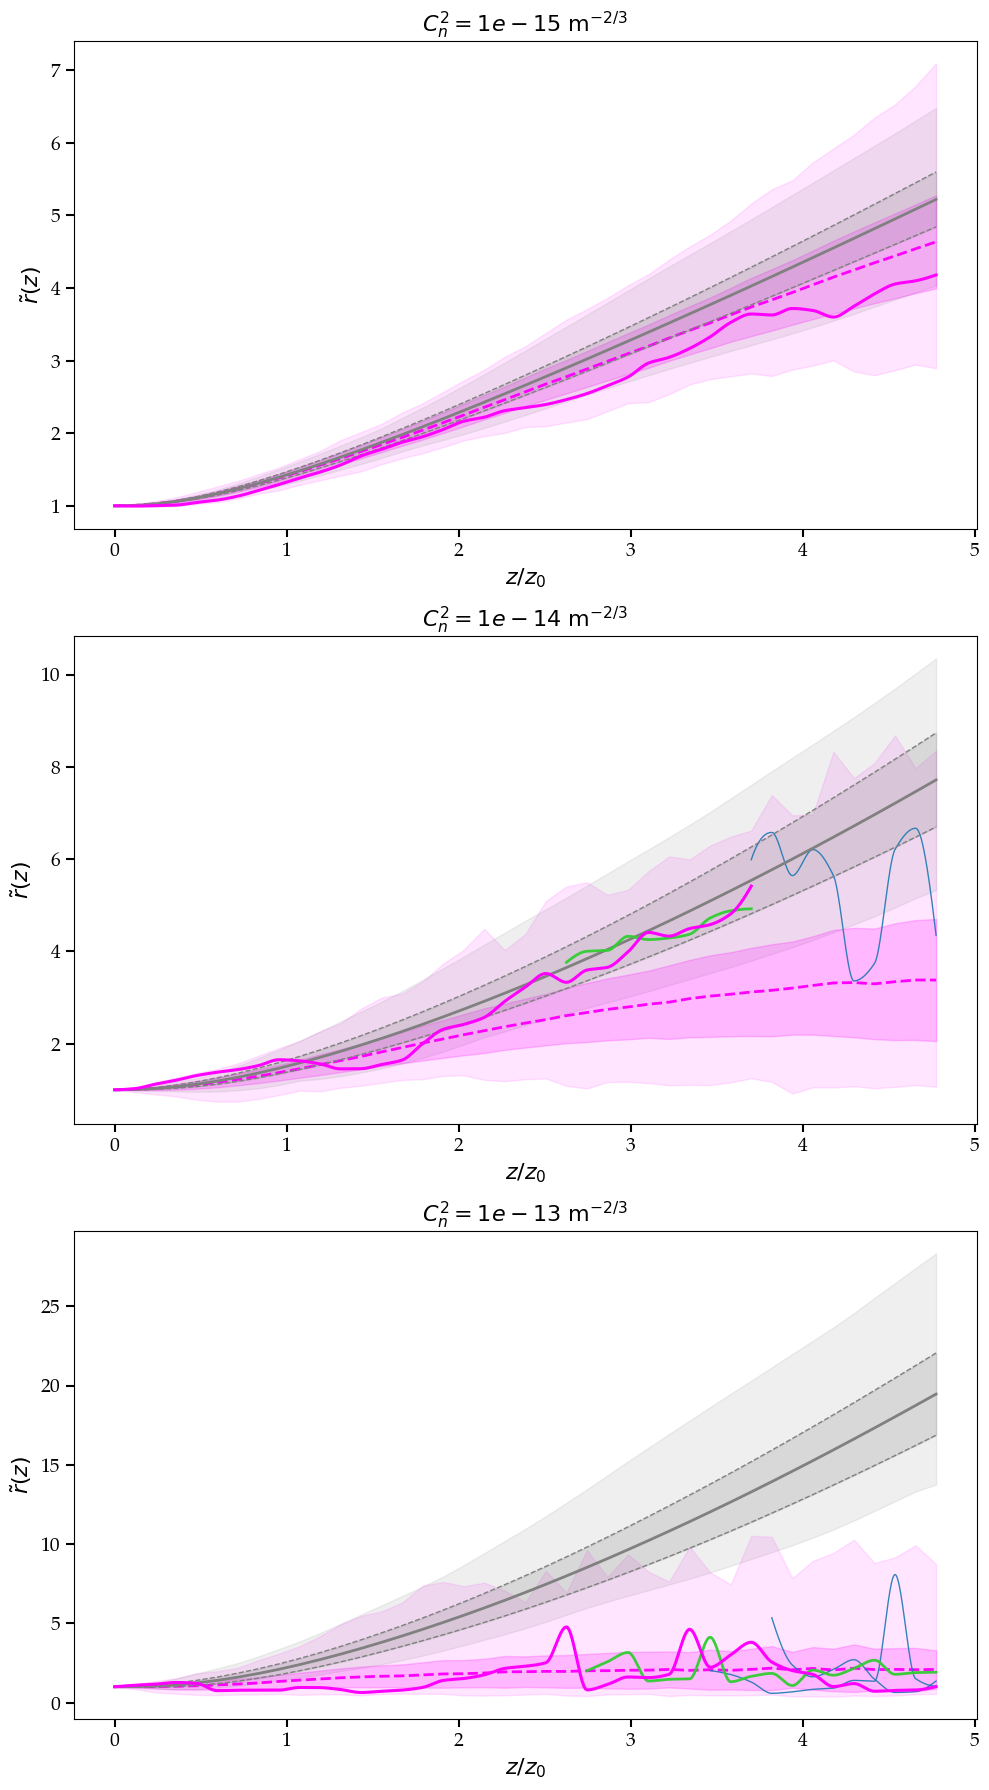

In [ ]:
#! ==========================================================
#! Imports
#! ==========================================================
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, center_of_mass
from skimage import measure
from matplotlib.path import Path
from scipy.interpolate import interp1d, PchipInterpolator

#! ==========================================================
#! Paths and I/O
#! ==========================================================
OUT_DIR       = r'F:\FSO_Turbulence_Dataset\Figures'
METRICS_DIR   = r'F:\FSO_Turbulence_Dataset\Metrics_Data'
PROP_BASE_DIR = r'F:\FSO_Turbulence_Dataset\Propagation_Datasets'

#! ==========================================================
#! Beam / Turbulence Grid (what we will actually plot)
#! ==========================================================
# We only plot a fixed inner scale and beam size, and sweep Cn2.
cn2_vals_plot = [1e-15, 1e-14, 1e-13]
w0_fixed      = 0.010
l0_fixed      = 0.005

#! ==========================================================
#! Propagation / Discretization
#! ==========================================================
L            = 3000.0      # propagation length [m]
wv1          = 500e-9      # wavelength [m]
dim          = 1024        # assumed transverse grid [px]
z_steps      = 41          # number of axial planes in each propagation file
num_iterations = 500       # number of Monte Carlo runs in metrics files
YLIM_TOP     = None        # set to a float to clamp y-axis

# How to normalize global MFR curves:
#   False -> MFR(z) / MFR(0)
#   True  -> MFR(z) / w0  (i.e. normalized by physical waist)
NORM_MFR_BY_W0 = False

# Which single propagation run to re-track and overlay (speckle widths vs z)
SINGLE_RUN_ITER = 409

#! ==========================================================
#! Tracking / Detection Parameters
#! ==========================================================
# These match your hotspot tracker logic
intensity_threshold_ratio = 0.3    # fraction of filtered max to accept as detection
death_floor_ratio         = 0.01   # kill track if RAW intensity < this * RAW max(z=0)
BANDPASS_R_LO             = 10     # low radius in Fourier (px)
BANDPASS_R_HI             = 80     # high radius in Fourier (px)
MIN_TRACK_LEN_FOR_PLOTTING = 8     # skip too-short tracks in the line overlays

# Normalize per-track widths by w0 at input:
#   True  -> r_1/e^2(z) / w0
#   False -> r_1/e^2(z) / (2 w0) [older style]
TRACK_WIDTHS_DIVIDE_BY_W0 = True

#! ==========================================================
#! Helpers for file naming
#! ==========================================================
def speckle_file_path(w0, cn2, l0):
    """Return path to aggregated initial-speckle-width HDF5 for given (w0, cn2, l0)."""
    return os.path.join(
        METRICS_DIR,
        f"InitialSpeckleWidth_Average_w0_{w0}_Cn2_{cn2}_l0_{l0}.h5"
    )

def metrics_file_path_for(cn2):
    """Return path to MFR/metric HDF5 given Cn2."""
    return os.path.join(METRICS_DIR, f"Cn2_{cn2}_Metrics_Data.h5")

def prop_file_and_key(w0, cn2, l0, it=SINGLE_RUN_ITER):
    """Return (file_path, dataset_key) for a single propagation realization."""
    beam_key = f"w0={w0}_Cn2={cn2}_l0={l0}_l=0_p=0_iteration={it}"
    file_path = os.path.join(
        PROP_BASE_DIR,
        f"Prop_Dataset_Cn2_{cn2}",
        f"{beam_key}.h5"
    )
    return file_path, beam_key

def zeta_axis(w0):
    """Return normalized axial coordinate z/z0 for this w0."""
    z0 = np.pi * w0**2 / wv1
    return np.linspace(0.0, L, z_steps) / z0

#! ==========================================================
#! Metrics loaders
#! ==========================================================
def load_speckle_stats(w0, cn2, l0):
    """
    Load precomputed, iteration-aggregated initial speckle widths.

    Returns:
        (zeta, mean, std, minv, maxv)
        or None if file is missing.
    """
    fpath = speckle_file_path(w0, cn2, l0)
    if not os.path.exists(fpath):
        return None

    with h5py.File(fpath, 'r') as f:
        zeta = f['zlist_norm'][:]
        widths_all = f['widths_per_iter'][:] 

    alive_counts = np.sum(~np.isnan(widths_all), axis=0)
    mask = alive_counts > 0
    if not np.any(mask):
        return None

    sp_mean = np.nanmean(widths_all, axis=0)
    sp_std  = np.nanstd(widths_all,  axis=0)
    sp_min  = np.nanmin(widths_all,  axis=0)
    sp_max  = np.nanmax(widths_all,  axis=0)
    return (zeta[mask], sp_mean[mask], sp_std[mask], sp_min[mask], sp_max[mask])

def load_mfr_stats(hf_metrics, w0, cn2, l0):
    """
    Collect MFR(z) over all iterations for this (w0, cn2, l0), then average.

    Returns:
        (zeta, mean, std, minv, maxv)
        or None if no valid iterations.
    """
    mfr_stack = np.full((num_iterations, z_steps), np.nan)
    for it in range(num_iterations):
        grp = f"w0={w0}_Cn2={cn2}_l0={l0}_l=0_p=0_iteration={it}"
        if grp not in hf_metrics:
            continue
        try:
            mfrarr = hf_metrics[grp]['mfrarr'][:]
            if mfrarr.size != z_steps:
                continue
            if NORM_MFR_BY_W0:
                mfr_norm = mfrarr / w0
            else:
                if mfrarr[0] == 0 or not np.isfinite(mfrarr[0]):
                    continue
                mfr_norm = mfrarr / mfrarr[0]
            mfr_stack[it, :] = mfr_norm
        except Exception:
            # ignore malformed entries
            pass

    alive = np.sum(~np.isnan(mfr_stack), axis=0) > 0
    if not np.any(alive):
        return None

    mfr_mean = np.nanmean(mfr_stack, axis=0)[alive]
    mfr_std  = np.nanstd(mfr_stack,  axis=0)[alive]
    mfr_min  = np.nanmin(mfr_stack,  axis=0)[alive]
    mfr_max  = np.nanmax(mfr_stack,  axis=0)[alive]
    zeta = zeta_axis(w0)
    return (zeta[alive], mfr_mean, mfr_std, mfr_min, mfr_max)

#! ==========================================================
#! Tracking primitives
#! ==========================================================
def get_bandpassed_spatial(intensity):
    """FFT -> annular bandpass -> inverse FFT -> magnitude."""
    fft_image = np.fft.fftshift(np.fft.fft2(intensity))
    h, w = intensity.shape
    cy, cx = h // 2, w // 2
    Y, X   = np.ogrid[:h, :w]
    distance = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask = (distance >= BANDPASS_R_LO) & (distance <= BANDPASS_R_HI)
    return np.abs(np.fft.ifft2(np.fft.ifftshift(fft_image * mask)))

def compute_1e2_radius_px(img, x, y):
    """
    Return 1/e^2 radius (in px) of the speckle centered at (x,y),
    using contour selection that actually encloses the point.
    """
    h, w = img.shape
    xi, yi = int(round(x)), int(round(y))
    if xi < 0 or xi >= w or yi < 0 or yi >= h:
        return 1.0
    peak = img[yi, xi]
    if not np.isfinite(peak) or peak <= 0:
        return 1.0

    level = float(peak) / np.e**2
    contours = measure.find_contours(img, level=level)

    # prefer contour that contains the point
    for cont in contours:
        if Path(cont[:, [1, 0]]).contains_point((x, y)):
            cx, cy = cont[:, 1], cont[:, 0]
            r_mean = float(np.mean(np.sqrt((cx - x)**2 + (cy - y)**2)))
            return max(1.0, r_mean)

    # fallback: radial sample
    max_r = 60
    thetas = np.linspace(0, 2*np.pi, 16, endpoint=False)
    hits = []
    for th in thetas:
        for r in range(1, max_r + 1):
            xt = int(round(x + r * np.cos(th)))
            yt = int(round(y + r * np.sin(th)))
            if xt < 0 or xt >= w or yt < 0 or yt >= h:
                hits.append(r)
                break
            if img[yt, xt] <= level:
                hits.append(r)
                break
    return max(1.0, float(np.mean(hits))) if hits else 1.0

def track_hotspots_iter409(file_path, beam_key):
    """
    Re-run hotspot tracking on a single propagation file (iteration=409 by default).
    Uses bandpass for detection and RAW intensities for width/death logic.
    Returns list of track dicts.
    """
    hotspot_tracks   = []
    original_max_raw = None
    initial_raw      = None

    with h5py.File(file_path, 'r') as hf:
        grp = hf[beam_key]
        for z in range(z_steps):
            U   = grp['Uout_real'][z]
            Iz  = np.abs(U)**2
            fil = get_bandpassed_spatial(Iz)

            if z == 0:
                initial_raw      = Iz.copy()
                original_max_raw = float(np.max(Iz)) if Iz.size else 0.0

            max_f = float(np.max(fil)) if fil.size else 0.0
            if max_f <= 0:
                # kill all alive
                for h in hotspot_tracks:
                    if h["alive"]:
                        h["alive"]  = False
                        h["death_z"] = z
                continue

            mask = fil > (intensity_threshold_ratio * max_f)
            labeled, num_features = label(mask)
            if num_features == 0:
                for h in hotspot_tracks:
                    if h["alive"]:
                        h["alive"]  = False
                        h["death_z"] = z
                continue

            centers = center_of_mass(fil, labeled, range(1, num_features + 1))
            claimed = [False] * len(centers)

            # update existing tracks
            for h in hotspot_tracks:
                if not h["alive"]:
                    continue
                last_x, last_y = h["last_pos"]
                r_thresh = max(1.0, float(h.get("min_avg_radius", 1.0)))

                best_i, best_d = None, np.inf
                for i, (y_c, x_c) in enumerate(centers):
                    if claimed[i]:
                        continue
                    d = np.hypot(x_c - last_x, y_c - last_y)
                    if d <= r_thresh and d < best_d:
                        best_d, best_i = d, i

                if best_i is None:
                    h["alive"]  = False
                    h["death_z"] = z
                    continue

                y_c, x_c = centers[best_i]

                # RAW death threshold
                if original_max_raw is not None:
                    raw_here = Iz[int(round(y_c)), int(round(x_c))]
                    if raw_here < death_floor_ratio * original_max_raw:
                        h["alive"]  = False
                        h["death_z"] = z
                        claimed[best_i] = True
                        continue

                # update position/history
                h["last_pos"] = (x_c, y_c)
                h["track"].append((z, x_c, y_c))

                w_px = float(compute_1e2_radius_px(Iz, x_c, y_c))
                if not np.isfinite(w_px) or w_px < 1.0:
                    w_px = 1.0
                h["radius_history"].append(w_px)
                run_mean = float(np.mean(h["radius_history"]))
                h["running_mean_radius"] = run_mean
                h["min_avg_radius"]      = min(h["min_avg_radius"], run_mean)

                claimed[best_i] = True

            # seed new tracks in unclaimed centers
            for i, (y_c, x_c) in enumerate(centers):
                if claimed[i]:
                    continue
                # reject if inside another alive track's min radius
                reject = False
                for h in hotspot_tracks:
                    if not h["alive"]:
                        continue
                    x0, y0 = h["last_pos"]
                    r0 = max(1.0, float(h.get("min_avg_radius", 1.0)))
                    if np.hypot(x_c - x0, y_c - y0) <= r0:
                        reject = True
                        break
                if reject:
                    continue

                init_I = initial_raw[int(round(y_c)), int(round(x_c))] if initial_raw is not None else 0.0
                w_px   = float(compute_1e2_radius_px(Iz, x_c, y_c))
                if not np.isfinite(w_px) or w_px < 1.0:
                    w_px = 1.0

                hotspot_tracks.append({
                    "initial_pos": (x_c, y_c),
                    "last_pos":    (x_c, y_c),
                    "alive":       True,
                    "creation_z":  z,
                    "death_z":     None,
                    "track":       [(z, x_c, y_c)],
                    "initial_intensity": float(init_I),
                    "radius_history":    [w_px],
                    "running_mean_radius": w_px,
                    "min_avg_radius":      w_px,
                })

    # keep only tracks with meaningful length
    return [h for h in hotspot_tracks if len(h["track"]) >= 3]

#! ==========================================================
#! Main plotting
#! ==========================================================
def plot_speckle_vs_mfr_stack():
    """Make one panel per Cn2, overlaying: (i) aggregated speckle widths, (ii) single-run track widths, (iii) MFR bands."""
    n_rows = len(cn2_vals_plot)
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, 18))
    if n_rows == 1:
        axes = [axes]
    fig.subplots_adjust(hspace=0.35)

    # transverse pixel size from critical sampling
    dx = np.sqrt(wv1 * L * dim) / dim
    zeta = zeta_axis(w0_fixed)

    for i, cn2 in enumerate(cn2_vals_plot):
        ax = axes[i]

        # ==================================================
        # 1) Aggregated initial speckle statistics
        # ==================================================
        speck = load_speckle_stats(w0_fixed, cn2, l0_fixed)
        if speck is not None:
            z_sp, sp_mean, sp_std, sp_min, sp_max = speck
            ax.fill_between(z_sp, sp_min, sp_max, alpha=0.10, color='magenta', zorder=1,
                            label='Speckle range (min–max)')
            ax.fill_between(z_sp, sp_mean - sp_std, sp_mean + sp_std, alpha=0.20,
                            color='magenta', zorder=2, label='Speckle ±1σ')
            ax.plot(z_sp, sp_mean, color='magenta', linewidth=2, linestyle='--',
                    label='Avg initial speckle (all iters)', zorder=3)

        # ==================================================
        # 2) Single iteration = 409: re-track and plot each speckle width(z)
        # ==================================================
        fpath, bkey = prop_file_and_key(w0_fixed, cn2, l0_fixed, SINGLE_RUN_ITER)
        tracks = None
        I_stack = None
        if os.path.exists(fpath):
            try:
                with h5py.File(fpath, 'r') as hf:
                    I_stack = np.abs(hf[bkey]['Uout_real'][:])**2   # [z, y, x]
                tracks = track_hotspots_iter409(fpath, bkey)
            except Exception:
                tracks = None

        def track_width_series_interp(h):
            """
            For a single track: compute per-z physical 1/e^2 radius from the contour
            that encloses that point; normalize; shape-preserving interpolate.
            """
            if I_stack is None:
                return None

            zs, widths = [], []
            for (z, x, y) in h["track"]:
                Iraw = I_stack[z]
                xi, yi = int(round(x)), int(round(y))
                if xi < 0 or xi >= dim or yi < 0 or yi >= dim:
                    continue
                peak = Iraw[yi, xi]
                if peak <= 0 or not np.isfinite(peak):
                    continue

                level = np.exp(-2) * peak
                contours = measure.find_contours(Iraw, level)
                selected = None
                for cont in contours:
                    if Path(cont[:, [1, 0]]).contains_point((x, y)):
                        selected = cont
                        break
                if selected is None:
                    continue

                cx, cy = selected[:, 1], selected[:, 0]
                dx_phys = (cx - x) * dx
                dy_phys = (cy - y) * dx
                r_mean = float(np.mean(np.sqrt(dx_phys**2 + dy_phys**2)))
                width_norm = (r_mean / w0_fixed) if TRACK_WIDTHS_DIVIDE_BY_W0 else (r_mean / (2.0 * w0_fixed))

                if np.isfinite(width_norm):
                    widths.append(max(0.0, width_norm))
                    zs.append(zeta[z])

            if not zs:
                return None

            zs = np.asarray(zs)
            widths = np.asarray(widths)
            order = np.argsort(zs)
            zs = zs[order]
            widths = widths[order]

            # shape-preserving where possible
            if len(zs) >= 3:
                f = PchipInterpolator(zs, widths)
                z_interp = np.linspace(zs[0], zs[-1], 500)
                w_interp = f(z_interp)
            elif len(zs) == 2:
                f = interp1d(zs, widths, kind='linear', bounds_error=False, fill_value="extrapolate")
                z_interp = np.linspace(zs[0], zs[-1], 200)
                w_interp = f(z_interp)
            else:
                return zs, widths

            w_interp = np.clip(w_interp, 0.0, None)
            return z_interp, w_interp

        if tracks:
            # find first-created and longest non-initial so we can color them differently
            min_cz = min(h["creation_z"] for h in tracks)
            init_candidates = [idx for idx, h in enumerate(tracks) if h["creation_z"] == min_cz]
            if len(init_candidates) > 1:
                initial_idx = max(init_candidates, key=lambda k: tracks[k]["initial_intensity"])
            else:
                initial_idx = init_candidates[0]

            noninit_indices = [k for k in range(len(tracks)) if k != initial_idx]
            longest_noninit_idx = max(noninit_indices, key=lambda k: len(tracks[k]["track"])) if noninit_indices else None

            # plot the ordinary tracks first
            for k, h in enumerate(tracks):
                if len(h["track"]) <= MIN_TRACK_LEN_FOR_PLOTTING:
                    continue
                if k == initial_idx or (longest_noninit_idx is not None and k == longest_noninit_idx):
                    continue
                sw = track_width_series_interp(h)
                if sw is None:
                    continue
                zc, wc = sw
                ax.plot(zc, wc, color='tab:blue', linewidth=1.0, alpha=0.9, zorder=3)

            # longest non-initial
            if longest_noninit_idx is not None and len(tracks[longest_noninit_idx]["track"]) > MIN_TRACK_LEN_FOR_PLOTTING:
                sw = track_width_series_interp(tracks[longest_noninit_idx])
                if sw is not None:
                    zc, wc = sw
                    ax.plot(zc, wc, color='limegreen', linewidth=2.0, alpha=0.95, zorder=4,
                            label=f'Longest non-initial (iter {SINGLE_RUN_ITER})')

            # earliest / strongest
            if len(tracks[initial_idx]["track"]) > MIN_TRACK_LEN_FOR_PLOTTING:
                sw = track_width_series_interp(tracks[initial_idx])
                if sw is not None:
                    zc, wc = sw
                    ax.plot(zc, wc, color='magenta', linewidth=2.2, alpha=1.0, zorder=5,
                            label=f'First detected (iter {SINGLE_RUN_ITER})')

        # ==================================================
        # 3) MFR overlays from metrics files
        # ==================================================
        metrics_path = metrics_file_path_for(cn2)
        if os.path.exists(metrics_path):
            with h5py.File(metrics_path, 'r') as hf_metrics:
                mfr = load_mfr_stats(hf_metrics, w0_fixed, cn2, l0_fixed)
        else:
            mfr = None

        if mfr is not None:
            z_m, mfr_mean, mfr_std, mfr_min, mfr_max = mfr
            lbl_range = ('MFR range (min–max, /$w_0$)' if NORM_MFR_BY_W0 else 'MFR range (min–max)')
            lbl_pm1s  = ('MFR ±1σ (MFR/$w_0$)'       if NORM_MFR_BY_W0 else 'MFR ±1σ (MFR/MFR$_0$)')
            lbl_mean  = ('MFR mean (MFR/$w_0$)'      if NORM_MFR_BY_W0 else 'MFR mean (MFR/MFR$_0$)')
            ax.fill_between(z_m, mfr_min, mfr_max, alpha=0.12, color='gray', zorder=1, label=lbl_range)
            ax.fill_between(z_m, mfr_mean - mfr_std, mfr_mean + mfr_std, alpha=0.20, color='gray', zorder=2, label=lbl_pm1s)
            ax.plot(z_m, mfr_mean, color='gray', linewidth=2, zorder=3, label=lbl_mean)
            ax.plot(z_m, mfr_mean + mfr_std, linestyle='--', linewidth=1, color='gray', zorder=3)
            ax.plot(z_m, mfr_mean - mfr_std, linestyle='--', linewidth=1, color='gray', zorder=3)

        # ==================================================
        # Axes cosmetics
        # ==================================================
        ax.grid(True, alpha=0, linestyle='--')
        if YLIM_TOP is not None:
            ax.set_ylim(top=YLIM_TOP)

        ax.tick_params(axis='both', which='major', labelsize=14, length=6, width=1.5)
        ax.set_xlabel(r'$z/z_0$', fontsize=16)
        ax.set_ylabel(r'$\tilde{r}(z)$', fontsize=16)
        ax.set_title(rf'$C_n^2 = {cn2:.0e}\ \mathrm{{m}}^{{-2/3}}$', fontsize=16, pad=6)

    out_path = os.path.join(
        OUT_DIR,
        f"Speckle_MFR_Stack_w0_{w0_fixed}_l0_{l0_fixed}_{'MFRw0' if NORM_MFR_BY_W0 else 'MFRMFR0'}_iter{SINGLE_RUN_ITER}.svg"
    )
    plt.tight_layout()
    # plt.savefig(out_path, format='svg', bbox_inches='tight')
    plt.show()
    # print("Saved figure:", out_path)

#! ==========================================================
#! Entry point
#! ==========================================================
if __name__ == "__main__":
    plot_speckle_vs_mfr_stack()


# Persistence Histograms

[Cn2=1e-15] N=120 | Δz/z0 = 1.891 ± 2.156 | Δz = 1361.875 ± 1215.187 m | frames = 18.16 ± 16.20
Saved: F:\FSO_Turbulence_Dataset\Figures\Histogram_Lifetime_over_z0_OVERLAY_w0_0.01_l0_0.005.svg


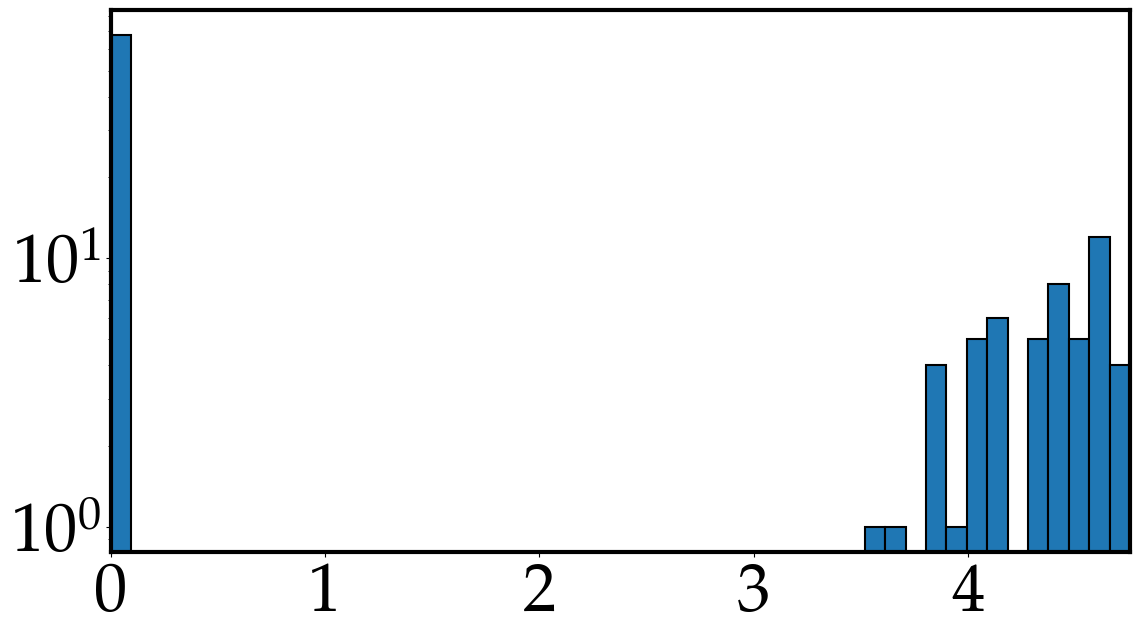

In [ ]:

#! ==========================================================
#! Imports
#! ==========================================================
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt


#! ==========================================================
#! User Parameters
#! ==========================================================

# --- Base paths ---
BASE_DATA_PATH = r'F:\FSO_Turbulence_Dataset\Propagation_Datasets'
METRICS_DIR    = os.path.join(os.path.dirname(BASE_DATA_PATH), "Metrics_Data")
FIG_DIR        = os.path.join(os.path.dirname(BASE_DATA_PATH), "Figures")
#os.makedirs(FIG_DIR, exist_ok=True)

# --- Beam / turbulence configuration ---
RAD      = 0.01
L0       = 0.005
CN2_LIST = [1e-15]   # can include multiple: [1e-15, 1e-14, 1e-13]

# --- Histogram / filtering ---
EXCLUDE_RIGHT_CENSORED = True   # True → exclude speckles that reach final frame
PCTL_MAX               = 99.5   # clip upper percentile to remove outliers
BINS                   = 50
NORMALIZE_HIST         = False  # True → normalize counts by N
SAVE_FIG               = True
ALPHA_BARS             = 0.3    # bar transparency

# --- Output ---
OUT_FNAME = f"Histogram_Lifetime_over_z0_OVERLAY_w0_{RAD}_l0_{L0}.svg"
OUT_PATH  = os.path.join(FIG_DIR, OUT_FNAME)

# --- Colors ---
COLOR_MAP = {
    1e-13: 'C0',
    1e-14: 'C1',
    1e-15: 'C2',
}


#! ==========================================================
#! Lifetime Extraction
#! ==========================================================
def collect_lifetimes(h5_path, exclude_right_censored=False):
    """Extract Δz/z₀, Δz (m), and lifetime (frames) from a time-series HDF5."""
    if not os.path.isfile(h5_path):
        raise FileNotFoundError(f"Missing HDF5 file: {h5_path}")

    ratios, lifetimes_m, lifetimes_frames = [], [], []

    with h5py.File(h5_path, "r") as H:
        lam     = float(H["metadata"].attrs["wavelength_m"])
        L_m     = float(H["metadata"].attrs["L_m"])
        z_range = np.array(H["metadata"]["z_range"][:], dtype=int)

        if len(z_range) < 2:
            raise ValueError("z_range has fewer than 2 frames.")
        dz = L_m / (len(z_range) - 1)

        # iterate through all iterations and speckle groups
        for iter_key in H:
            if iter_key == "metadata":
                continue
            for s_key in H[iter_key]:
                sgrp = H[iter_key][s_key]

                creation_z     = int(sgrp.attrs["creation_z"])
                death_z        = int(sgrp.attrs["death_z"])
                right_censored = bool(sgrp.attrs["right_censored"])

                if right_censored and exclude_right_censored:
                    continue

                if right_censored and death_z < 0:
                    frames = int(z_range[-1]) - creation_z
                else:
                    frames = death_z - creation_z

                if frames <= 0:
                    continue

                lifetime_m = frames * dz

                # width in meters at creation
                if "width_m" in sgrp:
                    w0_m = float(sgrp["width_m"][0])
                else:
                    dx_m  = float(H["metadata"].attrs["dx_m"])
                    w0_px = float(sgrp.attrs.get("initial_width_px", np.nan))
                    if not np.isfinite(w0_px) or w0_px <= 0:
                        continue
                    w0_m = w0_px * dx_m

                if not np.isfinite(w0_m) or w0_m <= 0:
                    continue

                z0 = np.pi * (w0_m ** 2) / lam
                if not np.isfinite(z0) or z0 <= 0:
                    continue

                ratios.append(lifetime_m / z0)
                lifetimes_m.append(lifetime_m)
                lifetimes_frames.append(frames)

    return np.array(ratios), np.array(lifetimes_m), np.array(lifetimes_frames)


#! ==========================================================
#! Print Statistics
#! ==========================================================
def print_stats(cn2, ratios, lifetimes_m, lifetimes_frames):
    """Print per-Cn² statistics for lifetime distributions."""
    n = ratios.size
    if n == 0:
        print(f"[Cn2={cn2:.0e}] N=0 (no valid lifetimes)")
        return

    dd = 1 if n > 1 else 0

#! ==========================================================
#! Plot Overlay Histogram
#! ==========================================================
def main():
    ratios_by_cn2 = {}
    lifetimes_m_by_cn2 = {}
    lifetimes_fr_by_cn2 = {}

    for cn2 in CN2_LIST:
        in_h5 = os.path.join(
            METRICS_DIR,
            f"Speckle_Width_TimeSeries_w0_{RAD}_Cn2_{cn2}_l0_{L0}.h5"
        )
        ratios, lifetimes_m, lifetimes_fr = collect_lifetimes(
            in_h5, exclude_right_censored=EXCLUDE_RIGHT_CENSORED
        )

        ratios_by_cn2[cn2] = ratios
        lifetimes_m_by_cn2[cn2] = lifetimes_m
        lifetimes_fr_by_cn2[cn2] = lifetimes_fr
        print_stats(cn2, ratios, lifetimes_m, lifetimes_fr)

    nonempty = [v for v in ratios_by_cn2.values() if v.size > 0]
    if not nonempty:
        print("No valid lifetimes found.")
        return

    all_vals = np.concatenate(nonempty)
    xmin = 0.0
    xmax = np.percentile(all_vals, PCTL_MAX)
    if not np.isfinite(xmax) or xmax <= 0:
        xmax = float(np.max(all_vals))

    edges = np.linspace(xmin, xmax, BINS + 1)
    widths = np.diff(edges)

    plt.figure(figsize=(11.5, 6.5))

    for cn2 in CN2_LIST:
        vals = ratios_by_cn2[cn2]
        if vals.size == 0:
            continue

        counts, _ = np.histogram(vals, bins=edges)
        yvals = counts / max(1, vals.size) if NORMALIZE_HIST else counts

        plt.bar(
            edges[:-1],
            yvals,
            width=widths,
            align='edge',
            alpha=1.0,
            edgecolor='black',
            linewidth=1.5,
            color='tab:blue',
            label=f"$C_n^2={cn2:.0e}$ (N={vals.size})"
        )

    plt.xlim([xmin, xmax])
    plt.yscale('log')
    plt.xticks(fontsize=48)
    plt.yticks(fontsize=48)
    plt.tight_layout()

    ax = plt.gca()
    for s in ax.spines.values():
        s.set_linewidth(3)
        s.set_edgecolor('black')

    if SAVE_FIG:
        plt.savefig(OUT_PATH, dpi=220, bbox_inches='tight')
        print(f"Saved: {OUT_PATH}")

    plt.show()


#! ==========================================================
#! Run
#! ==========================================================
if __name__ == "__main__":
    main()
